# Basic signals
Nesta atividades criaremos a nossa primeira **biblioteca de sinais digitais** com os sinais:

1. Delta: $\delta[n]$
2. Degrau: $u[n]$
3. Oscilação (periódico): $A \sin(\omega n + \phi)$
4. Exponencial
5. Aleatório (estocástico)


## Sinal delta, ou "impulso" - $\delta[n]$

<div style="text-align: center;">
    <img src="./figures/delta.png" alt="" width="500"/>
</div>


In [3]:
import numpy as np
import matplotlib.pyplot as plt

import sys
#sys.path.append('/home/kuntur/Documents')
#from lib.myPlotLib import *

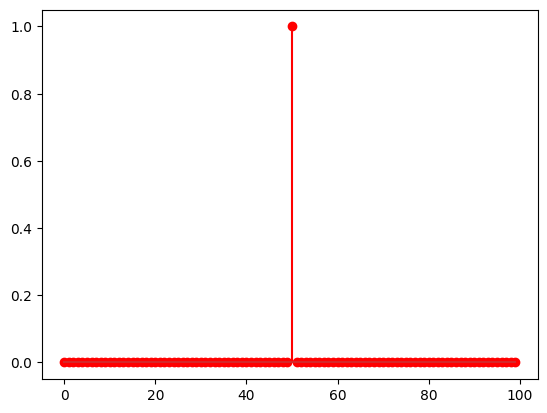

In [4]:
# 1. Sinal delta (v1.0) - Usando numpy
N      = 100
xn     = np.zeros(N)
k      = N // 2 # delay
xn[k]  = 1 # x[n-k]

# v2.0 - Usando listas
xn     = [0] * N
xn[k]  = 1
xn     = np.array(xn)

# Vetor de amostras
n      = np.arange(N)

fig, ax = plt.subplots()
ax.stem(n, xn, 'r')
plt.show()

## Sinal degrau - $u[n]$

<div style="text-align: center;">
    <img src="./figures/step.png" alt="" width="500"/>
</div>


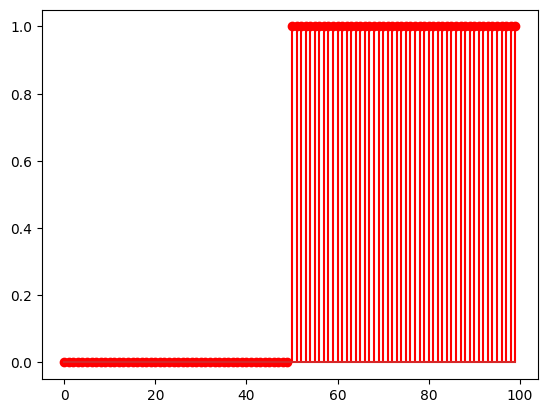

In [5]:
# 2. Degrau (v1.0) - Usando numpy
un         = np.zeros(N)
un[N//2:]  = 1

# v2.0 - Usando listas
un = [0] * (N // 2) + [1] * (N // 2)
un = np.array(un)

# Vetor de amostras
n  = np.arange(N)

fig, ax = plt.subplots()
ax.stem(n, un, 'r')
plt.show()

## Sinal oscilatório, ou periódico - $A \sin(\omega n + \phi)$

<div style="text-align: center;">
    <img src="./figures/sine.png" alt="" width="500"/>
</div>


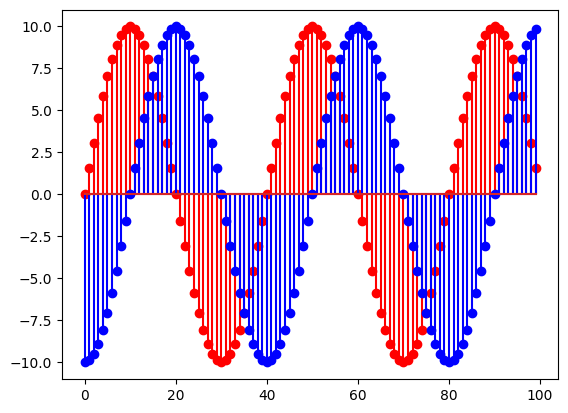

In [6]:
# 4. Sinal periodico
N   = 100 # numero de amostras
k   = 0 # delay
n   = np.arange(N) # vetor de amostras

A    = 10
P    = 40 # periodo do sinal
wo   = (2 * np.pi) / P # frequencia digital
phi  = 0 # fase
xn   = A * np.sin(wo * n + phi)
yn   = A * np.sin(wo * n + phi + 3*np.pi/2)

# Plotagem
fig, ax = plt.subplots()
ax.stem(n, xn, 'ro')
ax.stem(n, yn, 'bd')
plt.show()

## Sinal exponencial - $|a|^{n} u[n]$

<div style="text-align: center;">
    <img src="./figures/exp.png" alt="" width="500"/>
</div>


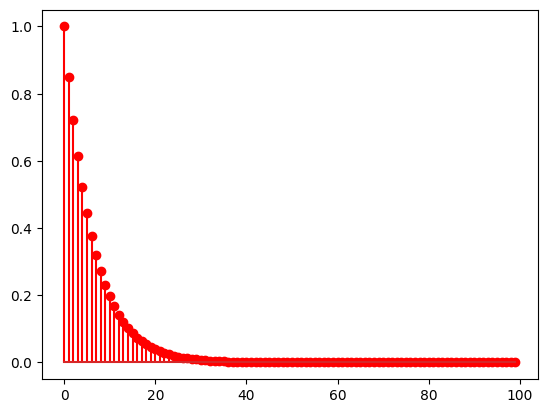

In [7]:
# 3. Exponencial
a  = 0.85
yn = np.abs(a) ** n

fig, ax = plt.subplots()
ax.stem(n, yn, 'r')
plt.show()

## Sinal aleatório - $x[n] = ?$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian.png" alt="" width="500"/>
    <img src="./figures/random-uniform.png" alt="" width="500"/>
</div>


### Aleatório Gaussiano - $\mathcal{X} \sim \mathcal{N}(\mu, \sigma)$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian-dist.png" alt="" width="500"/>
</div>


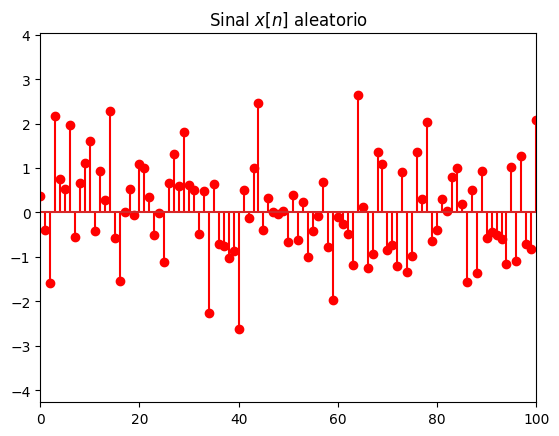

In [8]:
# 5. Sinal aleatorio (distribuicao Gaussiana)
N  = 10000
n  = np.arange(N) # vetor de amostras

xn = np.random.normal(0, 1, N) # Gaussiano (normal)

# Plot
fig, ax = plt.subplots(1)
ax.stem(n, xn, 'ro')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
plt.show()

Plote o **histograma** deste sinal.

**Dica:** Use `ax.hist`


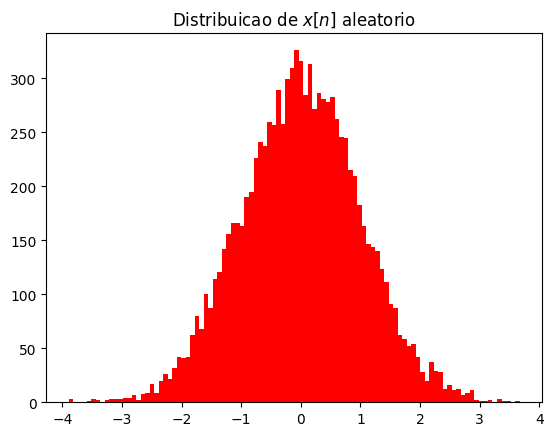

In [9]:
fig, ax = plt.subplots()
ax.hist(xn, 100, color='r')
ax.set_title(r'Distribuicao de $x[n]$ aleatorio')
plt.show()

### Aleatório uniforme - $\mathcal{X} \sim \mathcal{U} \{a, b\}$

<div style="text-align: center;">
    <img src="./figures/random-uniform-dist.png" alt="" width="500"/>
</div>


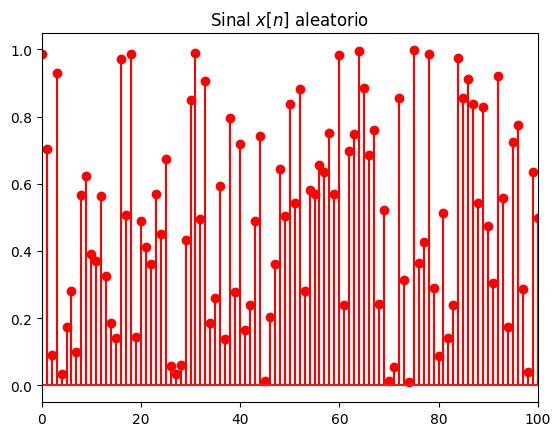

In [10]:
# 5. Sinal aleatorio (distribuicao uniforme)
N  = 10000
n  = np.arange(N) # vetor de amostras

xn = np.random.uniform(0, 1, N) # uniforme

# Plot
fig, ax = plt.subplots(1)
ax.stem(n, xn, 'ro')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
plt.show()

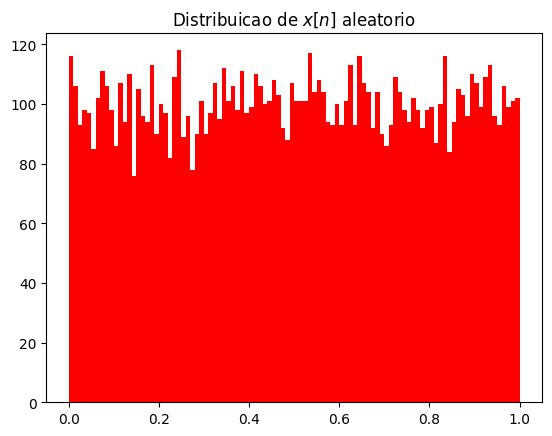

In [11]:
fig, ax = plt.subplots()
ax.hist(xn, 100, color='r')
ax.set_title(r'Distribuicao de $x[n]$ aleatorio')
plt.show()

## Minha biblioteca de sinais básicos

In [14]:
def SIGNAL(N=100, signal='delta', params=None):
    if signal == 'delta':
        '''
        Delta (impulse)
        '''
        x = np.zeros(N)
        center = N // 2
        x[center] = 1

    if signal == 'step':
        '''
        Step
        '''
        x = np.concatenate((np.zeros(N // 2), np.ones(N // 2)))

    if signal == 'exp':
        '''
        Exponential
          - a: base of the exponential
        '''
        a = params[0]
        n = np.arange(N) - (N // 2)
        base = SIGNAL(N, signal='step')
        x = (np.abs(a) ** n) * base

    if signal == 'osc':
        '''
        Oscillation
          - period
          - phase
        '''
        n = np.arange(N)
        period = params[0]
        phase = params[1]
        w = (2 * np.pi) / period
        x = np.sin(w * n + phase)

    if signal == 'random':
        '''
        Random
        '''
        if params == 'uniform':
            x = np.random.uniform(low=-1.5, high=1.5, size=N)
        else:
            '''
            Gaussian
            '''
            x = np.random.normal(loc=0.0, scale=1.0, size=N)

    return x

In [15]:
def SIGNALplot(x):
    fig, ax = plt.subplots()
    ax.stem(x, 'b')
    plt.show()

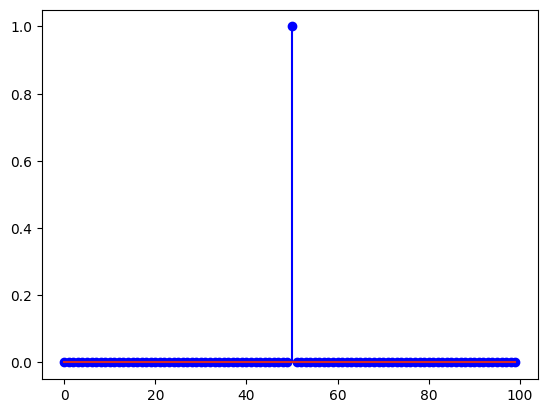

In [16]:
SIGNALplot(SIGNAL(100, 'delta'))

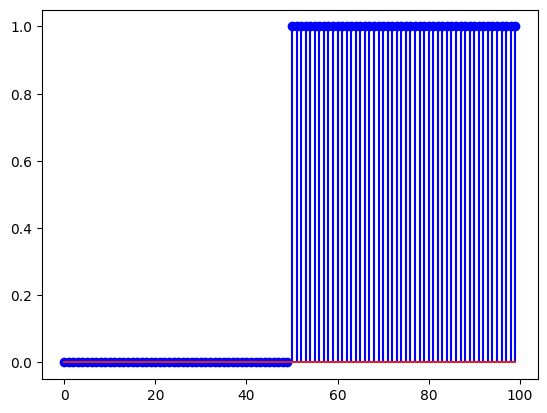

In [17]:
SIGNALplot(SIGNAL(100, 'step'))

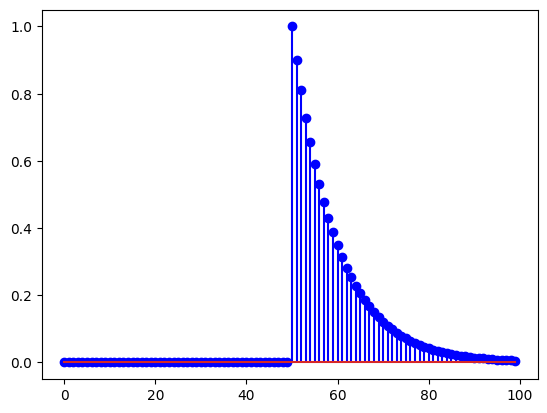

In [23]:
SIGNALplot(SIGNAL(100, 'exp', [0.9]))

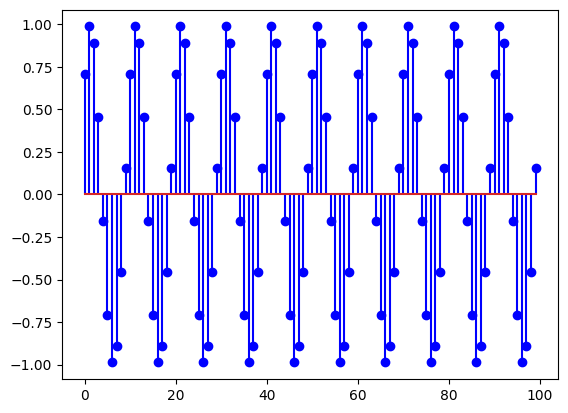

In [24]:
SIGNALplot(SIGNAL(100, 'osc', [10, np.pi/4]))

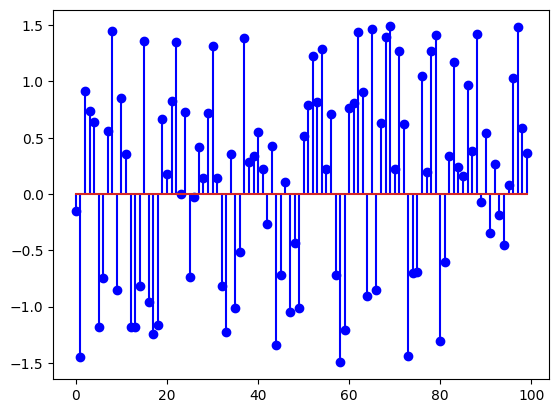

In [20]:
SIGNALplot(SIGNAL(100, 'random', 'uniform'))

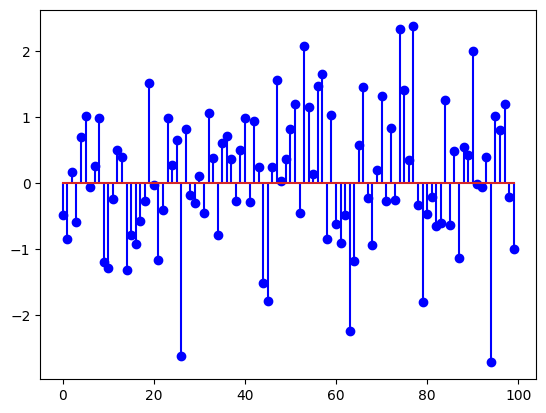

In [21]:
SIGNALplot(SIGNAL(100, 'random'))